# Test out source code

In [1]:
using Pkg 
Pkg.activate("../.")
#Pkg.instantiate()
include("../src/model.jl")
function certianty_equivelent(prob,state)
    inverse_utility(prob.V(state)*(1-prob.δ),prob.p.γ)
end 

  Activating project at `~/github/FisheriesInsuranceModel`
Precompiling ValueFunctionIterations
  ✓ Interpolations → InterpolationsUnitfulExt
  ✓ ValueFunctionIterations
  2 dependencies successfully precompiled in 27 seconds. 100 already precompiled.
[ Info: Precompiling ValueFunctionIterations [dc40bd75-440c-4f41-8fab-869df1870d2c]
Precompiling StatsFunsChainRulesCoreExt
  ✓ StatsFuns → StatsFunsChainRulesCoreExt
  1 dependency successfully precompiled in 6 seconds. 23 already precompiled.
[ Info: Precompiling StatsFunsChainRulesCoreExt [d41313fe-2684-5453-9fef-703f5fa397f4]
┌ Warning: Module SpecialFunctionsChainRulesCoreExt with build ID fafbfcfd-75ee-e7f6-0008-c25ac63eebf8 is missing from the cache.
│ This may mean SpecialFunctionsChainRulesCoreExt [9eb7bdd4-e44c-55fc-b9cc-1a32cb715188] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
┌ Error: Error during loading of extension SpecialFunctionsChainRulesCoreExt of SpecialFunctions, use

certianty_equivelent (generic function with 1 method)

In [6]:
using Pkg 
#Pkg.activate("../.")
#Pkg.instantiate()
using Plots, DataFrames, CSV, Random
function value_diffs(params)
    #params = "no_RA_short"
    Nκ = "20"; Nη = "2"; Ns_grid = "24"; Nb_grid = "24"; NΔb_grid = "18"; Nquad = "50"
    include("../src/model.jl"); include("../src/plotting.jl")
    include("../parameters/$params.jl")

    ###################################
    ####  Define random variables #####
    ###################################
    X, Xmc = init_ranom_variables(p; Nquad = parse(Int,Nquad))

    # define state variables and check the grid 
    ######################################
    ####  Define state varible grids #####
    ######################################
    # check paramters to get min and max values
    bmax = 0.5; bmin = -3.5; Nb_grid = parse(Int,Nb_grid)
    Δbmax = 1.25; Δbmin = -1.0; NΔb_grid = parse(Int,NΔb_grid)
    if occursin("short", params)
        bmax = 1.0; bmin = -3.0
        Δbmax = 2; Δbmin = -1.25
    elseif occursin("long", params)
        bmax = 0.0; bmin = -4.5
        Δbmax = 0.75; Δbmin = -0.75
    end 
    # stock 

    states, m, f, h, y = simulate_trajectory(p,X,5000)
    Plots.scatter(states[1,:], states[2,:])
    b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
    Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax
    plt = Plots.scatter!(b_grid,[0.0])
    Plots.scatter!(zeros(length(Δb_grid)),Δb_grid)


    # savings 
    smax = 2.5; smin = -4.0; Ns_grid = parse(Int,Ns_grid)
    s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
    plt = Plots.scatter(exp.(s_grid),s_grid, label = "Savings", xlabel = "Savings", ylabel = "log savings")

    state_grid = [s_grid,b_grid,Δb_grid]
    ###############################
    ####  Define action grid  #####
    ###############################
    κmin = 0.01; κmax = 0.99; Nκ = parse(Int,Nκ)
    κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
    ηmin = 0.0; ηmax=1e-10; Nη = parse(Int,Nη)
    η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
    action_grid = [κ_grid,η_grid]

    # plot grid
    k=0; u_grid = zeros(2,length(κ_grid)*length(η_grid))
    for (i,j) in Iterators.product(1:length(κ_grid),1:length(η_grid))
        k +=1
        u_grid[:,k] = vcat(κ_grid[i],η_grid[j]) 
    end
    u_grid=u_grid[:,reshape(mapslices(sum,u_grid,dims = 1).<=1,length(κ_grid)*length(η_grid))]
    plt = Plots.scatter(u_grid[1,:],u_grid[2,:], xlabel = "Consumption", ylabel= "Premiums", label = "")


    #######################################
    ####  Strike and index functions  #####
    #######################################
    function strike(s,p)
        return 0.5*(p.b_target +p.b_limit) 
    end

    function index(s,X)
        return exp(s[1])+X[1]
    end 

    ##################################
    ####  Set up dynamic program  ####
    ##################################
    δ = 0.95
    prob, El = init(action_grid,state_grid,δ,p,X,index,strike)
    prob_insurance, El = init(action_grid,state_grid,δ,p,X,index,strike)

    ##################################
    ####  load in solutions       ####
    ##################################
    load_solution(prob,"../results/no_insurance_$params/sol.jld2")
    load_solution(prob_insurance,"../results/$params/sol.jld2")
    Random.seed!(123)
    sim_states, m, f, h, y = simulate_trajectory(p,Xmc,2000)
    s0 = vcat([1.0,log(-1*p.s̄)],sim_states[:,rand(500:2000)])

    function average_diff(s,states)
        st = log(s - p.s̄)
        V = mean(mapslices(s -> certianty_equivelent(prob_insurance,vcat([1.0,st],s)), states, dims = 1))
        V_no_I = mean(mapslices(s -> certianty_equivelent(prob,vcat([1.0,st],s)), states, dims = 1))
        return (V - V_no_I)/V_no_I
    end
    st_vals = [0.25, 0.5, 1.0, 2.0, 3.5] .+ p.s̄
    values = broadcast(s -> 100*average_diff(s,sim_states),st_vals )
    diff = DataFrame(savings = st_vals, increase = values)
    CSV.write("../results/$params/value_diff.csv", diff)
    return nothing
end 

value_diffs (generic function with 1 method)

In [39]:
value_diffs("no_RA_short")

In [40]:
#value_diffs("no_RA_short")
value_diffs("no_RA_intermidiate")
value_diffs("no_RA_long")


In [41]:
value_diffs("RA_short")
value_diffs("RA_intermidiate")
value_diffs("RA_long")

In [ ]:
value_diffs("RA_short")
value_diffs("RA_intermidiate")
value_diffs("RA_long")

In [ ]:
#value_diffs("RA_intermidiate_higher_frequency")
value_diffs("RA_intermidiate_higher_severity")
#value_diffs("RA_intermidiate_longer_duration")

In [101]:
value_diffs("RA_long_higher_frequency")
value_diffs("RA_long_higher_severity")
value_diffs("RA_long_longer_duration")

In [93]:

#value_diffs("RA_short_higher_frequency")
value_diffs("RA_short_higher_severity")
#value_diffs("RA_short_longer_duration")

In [96]:
value_diffs("no_RA_long_higher_frequency")
value_diffs("no_RA_long_higher_severity")
value_diffs("no_RA_long_longer_duration")

In [106]:
df = CSV.read("../results/RA_long_longer_duration/value_diff.csv",DataFrame)
df.increase

4-element Vector{Float64}:
 12.9806092065836
 13.364840381430074
 13.62832273191166
 12.861816427143625

In [108]:
value_diffs("RA_intermidiate_lower_frequency")
value_diffs("RA_intermidiate_higher_frequency_2")
value_diffs("RA_intermidiate_higher_frequency_3")

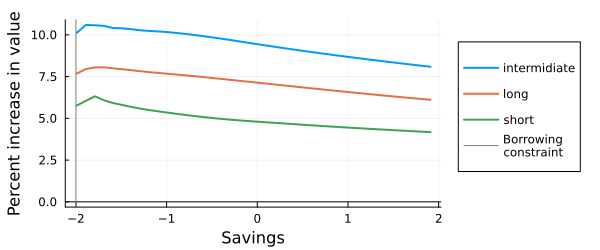

In [205]:
df = CSV.read("../results/no_RA_intermidiate/value_diff.csv",DataFrame)
Plots.plot(df.savings,df.increase, label = "intermidiate", width = 2)
df = CSV.read("../results/no_RA_long/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "long", width = 2)
df = CSV.read("../results/no_RA_short/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "short", width = 2)
Plots.hline!([0.0], color = "black", label = "")
Plots.vline!([-2], color = "grey", label = "Borrowing \nconstraint")
Plots.plot!(size = (600,250), xlabel = "Savings", ylabel = "Percent increase in value",
            legend = :outerright, margin = 3Plots.Measures.mm)

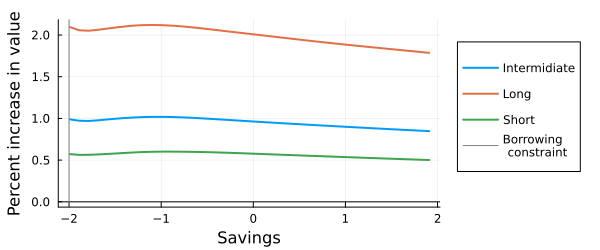

In [313]:
df = CSV.read("../results/RA_intermidiate/value_diff.csv",DataFrame)
Plots.plot(df.savings,df.increase, label = "Intermidiate", width = 2)
df = CSV.read("../results/RA_long/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "Long", width = 2)
df = CSV.read("../results/RA_short/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "Short", width = 2)
Plots.hline!([0.0], color = "black", label = "")
Plots.vline!([-2], color = "grey", label = "Borrowing \n constraint")
Plots.plot!(size = (600,250), xlabel = "Savings", ylabel = "Percent increase in value",
            legend = :outerright, margin = 3Plots.Measures.mm)

In [9]:
#value_diffs("RA_intermidiate_lower_y0")
value_diffs("no_RA_intermidiate_higher_y0")

In [12]:
value_diffs("RA_intermidiate_lower_blimit")

In [208]:
value_diffs("no_RA_intermidiate_higher_k")
value_diffs("no_RA_intermidiate_higher_y0")
value_diffs("no_RA_intermidiate_lower_y0")

In [7]:
value_diffs("RA_intermidiate")
value_diffs("RA_intermidiate_higher_k")
value_diffs("RA_intermidiate_higher_k_2")
value_diffs("RA_intermidiate_higher_k_3")

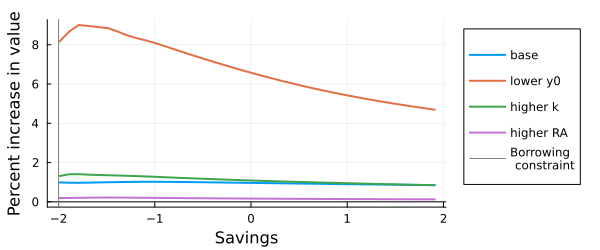

In [210]:
df = CSV.read("../results/RA_intermidiate/value_diff.csv",DataFrame)
Plots.plot(df.savings,df.increase, label = "base", width = 2)
df = CSV.read("../results/RA_intermidiate_lower_y0/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "lower y0", width = 2)
df = CSV.read("../results/RA_intermidiate_higher_k/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "higher k", width = 2)
df = CSV.read("../results/RA_intermidiate_higher_RA/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "higher RA", width = 2)
Plots.hline!([0.0], color = "black", label = "")
Plots.vline!([-2], color = "grey", label = "Borrowing \n constraint")
Plots.plot!(size = (600,250), xlabel = "Savings", ylabel = "Percent increase in value",
            legend = :outerright, margin = 3Plots.Measures.mm)

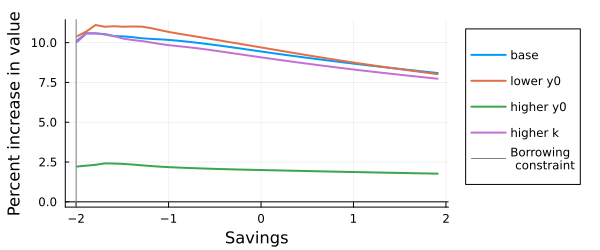

In [212]:
df = CSV.read("../results/no_RA_intermidiate/value_diff.csv",DataFrame)
Plots.plot(df.savings,df.increase, label = "base", width = 2)
df = CSV.read("../results/no_RA_intermidiate_lower_y0/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "lower y0", width = 2)
df = CSV.read("../results/no_RA_intermidiate_higher_y0/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "higher y0", width = 2)
df = CSV.read("../results/no_RA_intermidiate_higher_k/value_diff.csv",DataFrame)
Plots.plot!(df.savings,df.increase, label = "higher k", width = 2)
Plots.hline!([0.0], color = "black", label = "")
Plots.vline!([-2], color = "grey", label = "Borrowing \n constraint")
Plots.plot!(size = (600,250), xlabel = "Savings", ylabel = "Percent increase in value",
            legend = :outerright, margin = 3Plots.Measures.mm)

In [293]:
using Pkg, Random
#Pkg.activate("../.")
#Pkg.instantiate()
using Plots, DataFrames, CSV
function coverage_levels(params; T = 500)
    #params = "no_RA_short"
    Nκ = "15"; Nη = "10"; Ns_grid = "24"; Nb_grid = "24"; NΔb_grid = "18"; Nquad = "10"
    include("../src/model.jl"); include("../src/plotting.jl")
    include("../parameters/$params.jl")

    ###################################
    ####  Define random variables #####
    ###################################
    X, Xmc = init_ranom_variables(p; Nquad = parse(Int,Nquad))

    # define state variables and check the grid 
    ######################################
    ####  Define state varible grids #####
    ######################################
    # check paramters to get min and max values
    bmax = 0.5; bmin = -3.5; Nb_grid = parse(Int,Nb_grid)
    Δbmax = 1.25; Δbmin = -1.0; NΔb_grid = parse(Int,NΔb_grid)
    if occursin("short", params)
        bmax = 1.0; bmin = -3.0
        Δbmax = 2; Δbmin = -1.25
    elseif occursin("long", params)
        bmax = 0.0; bmin = -4.5
        Δbmax = 0.75; Δbmin = -0.75
    end 
    # stock 
    Random.seed!(1234)
    states, m, f, h, y = simulate_trajectory(p,X,T)
    b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
    Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax


    # savings 
    smax = 2.5; smin = -4.0; Ns_grid = parse(Int,Ns_grid)
    s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
    state_grid = [s_grid,b_grid,Δb_grid]

    ###############################
    ####  Define action grid  #####
    ###############################
    κmin = 0.01; κmax = 0.99; Nκ = parse(Int,Nκ)
    κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
    ηmin = 0.0; ηmax=0.2; Nη = parse(Int,Nη)
    η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
    action_grid = [κ_grid,η_grid]

    # plot grid
    k=0; u_grid = zeros(2,length(κ_grid)*length(η_grid))
    for (i,j) in Iterators.product(1:length(κ_grid),1:length(η_grid))
        k +=1
        u_grid[:,k] = vcat(κ_grid[i],η_grid[j]) 
    end
    u_grid=u_grid[:,reshape(mapslices(sum,u_grid,dims = 1).<=1,length(κ_grid)*length(η_grid))]


    #######################################
    ####  Strike and index functions  #####
    #######################################
    function strike(s,p)
        return 0.5*(p.b_target +p.b_limit) 
    end

    function index(s,X)
        return exp(s[1])+X[1]
    end 

    ##################################
    ####  Set up dynamic program  ####
    ##################################
    δ = 0.95
    prob, El = init(action_grid,state_grid,δ,p,X,index,strike)

    ##################################
    ####  load in solutions       ####
    ##################################
    load_solution(prob,"../results/no_insurance_$params/sol.jld2")
    load_solution(prob_insurance,"../results/$params/sol.jld2")



    function average_coverage(s,states)
        print(s," ")
        st = log(s - p.s̄)
        Elt = broadcast(t->El(states[1,t],states[2,t],states[3,t]),1:(size(states)[2]-1)) # Expected losses 
        η̄t = broadcast(t->price_per_exposure(Elt[t],p.cf,p.cv), 1:(size(states)[2]-1))
        function policy(t)
            state = vcat([1.0,s],states[:,t])
            ValueFunctionIterations.ENPV(state, prob.u(state,prob.p), prob.X(state,prob.p), prob.R, prob.F, prob.p, prob.δ, prob.V)[2]
        end
        ηt = broadcast(t->policy(t)[2], 1:(size(states)[2]-1))
        return mean(ηt./ η̄t)
    end
    st_vals = -1.99:0.5:2.01
    values = broadcast(s -> average_coverage(s,states),st_vals )
    diff = DataFrame(savings = st_vals, increase = values)
    CSV.write("../results/$params/coverage.csv", diff)
    return values, st_vals, states
end 

coverage_levels (generic function with 2 methods)

-1.99 -1.49 -0.99 -0.49 0.01 0.51 1.01 1.51 2.01 

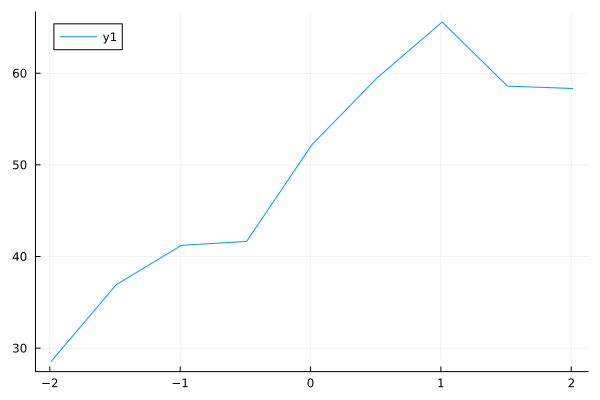

In [302]:
vals, st, states = coverage_levels("no_RA_intermidiate", T = 1000)
Plots.plot(st,vals)

In [303]:
vals_long, st_vals, states_long = coverage_levels("no_RA_long", T = 2000)
vals_short, st_vals, states_short = coverage_levels("no_RA_short", T = 250)

-1.99 -1.49 -0.99 -0.49 0.01 0.51 1.01 1.51 2.01 -1.99 -1.49 -0.99 -0.49 0.01 0.51 1.01 1.51 2.01 

([9.542523866636646, 11.497244338066533, 15.085016781618666, 18.179719948060796, 19.822770776754123, 22.715752837060425, 21.75709614149247, 24.111400003086217, 18.021414575626956], -1.99:0.5:2.01, [-0.916290731874155 -0.9247459881586957 … -1.0754897683933684 -0.7760961523853435; 0.0 -0.008455256284540691 … 0.20160625457784564 0.29939361600802494; 1.0 1.0 … 1.0 1.0])

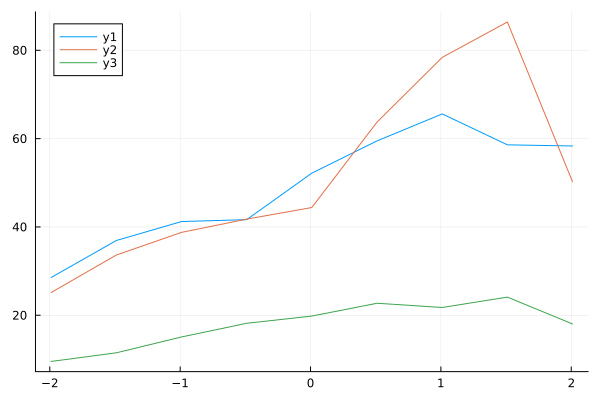

In [304]:
Plots.plot(st_vals,vals)
Plots.plot!(st_vals,vals_long)
Plots.plot!(st_vals,vals_short)

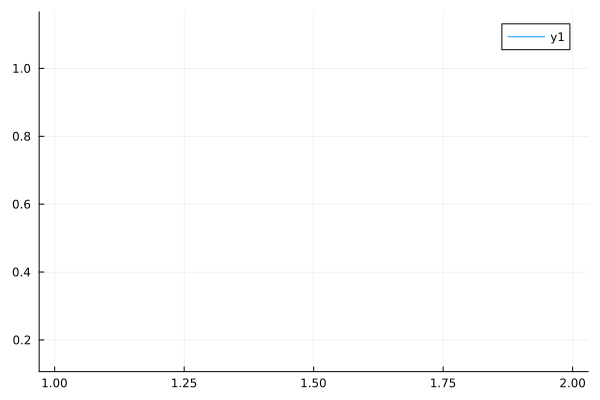

In [268]:
Plots.plot(exp.(states[1,:]))


In [81]:
using Pkg, Random
# Pkg.activate("../.")
# Pkg.instantiate()
using Plots, DataFrames, CSV
include("../src/model.jl"); include("../src/plotting.jl")
function coverage_levels(params)
    #params = "no_RA_short"
    Nκ = "20"; Nη = "20"; Ns_grid = "20"; Nb_grid = "20"; NΔb_grid = "3"; Nquad = "10"
    include("../src/model.jl"); include("../src/plotting.jl")
    include("../src/insurnace_contracts.jl")
    include("../parameters/$params.jl")

    ###################################
    ####  Define random variables #####
    ###################################
    X, Xmc = init_ranom_variables(p; Nquad = parse(Int,Nquad))

    # define state variables and check the grid 
    ######################################
    ####  Define state varible grids #####
    ######################################
    # check paramters to get min and max values
    bmax = 0.0; bmin = -2.5; Nb_grid = parse(Int,Nb_grid)
    Δbmax = 0.5; Δbmin = -0.5; NΔb_grid = parse(Int,NΔb_grid)

    # stock 
    Random.seed!(1234)
    b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
    Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax


    # savings 
    smax = log(2.0); smin = -2.5; Ns_grid = parse(Int,Ns_grid)
    s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
    state_grid = [s_grid,b_grid,Δb_grid]

    ###############################
    ####  Define action grid  #####
    ###############################
    κmin = 0.01; κmax = 0.99; Nκ = parse(Int,Nκ)
    κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
    ηmin = 0.0; ηmax=0.2; Nη = parse(Int,Nη)
    η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
    action_grid = [κ_grid,η_grid]

    # plot grid
    k=0; u_grid = zeros(2,length(κ_grid)*length(η_grid))
    for (i,j) in Iterators.product(1:length(κ_grid),1:length(η_grid))
        k +=1
        u_grid[:,k] = vcat(κ_grid[i],η_grid[j]) 
    end
    u_grid=u_grid[:,reshape(mapslices(sum,u_grid,dims = 1).<=1,length(κ_grid)*length(η_grid))]


    #######################################
    ####  Strike and index functions  #####
    #######################################
    function strike(s,p)
        return 0.5*(p.b_target +p.b_limit) 
    end

    function index(s,X)
        return exp(s[1])+X[1]
    end 

    ##################################
    ####  Set up dynamic program  ####
    ##################################
    δ = 0.95
    prob, El = init(action_grid,state_grid,δ,p,X,index,strike)
    states = prob.V.states[:,prob.V.states[1,:].==1]

    dims = prob.V.Bslines[1].dims

    ##################################
    ####  load in solutions       ####
    ##################################
    load_solution(prob,"../results/$params/sol.jld2")

    ##################################
    ####  calcaulte policy        ####
    ##################################

    u_opt = ValueFunctionIterations.policy(states,prob.u,prob.X,prob.R,prob.F,prob.p,prob.δ,prob.V)
    η_s = reshape(u_opt[2,:],dims...)
    η̄_s =  mapslices(s -> price_per_exposure(El(s[3],s[4],s[5]),prob.p.cf,prob.p.cv),states,dims = 1)
    η̄_s = reshape(η̄_s,dims...)
    u = [1e-10,0.0]
    function insurance_claims(s)
        nodes = prob.X(s,prob.p).nodes
        weights = prob.X(s,prob.p).weights
        weights = weights[nodes[5,:].==1.0] 
        weights = weights ./ sum(weights)
        nodes = nodes[:,nodes[5,:].==1.0] 
        claim = mapslices(x -> index_insurance(index(prob.F(s,u,x,prob.p)[3:5],[0.0]),strike(s,prob.p),1,1), nodes, dims = 1)
        sum(claim' .* weights )
    end 
    claims =  mapslices(s -> insurance_claims(s),states,dims = 1)
    claims = reshape(claims,dims...)

    return η_s, η̄_s, claims, state_grid
end 


coverage_levels (generic function with 1 method)

In [82]:
η_s_short, η̄_s_short, claims_short, state_grid_short = coverage_levels("RA_short")
print("short ")
η_s_intermediate, η̄_s_intermediate, claims_intermediate, state_grid_intermediate = coverage_levels("RA_intermidiate")
print("int ")
η_s_long, η̄_s_long, claims_long, state_grid_long = coverage_levels("RA_long")
print("long")

short int long

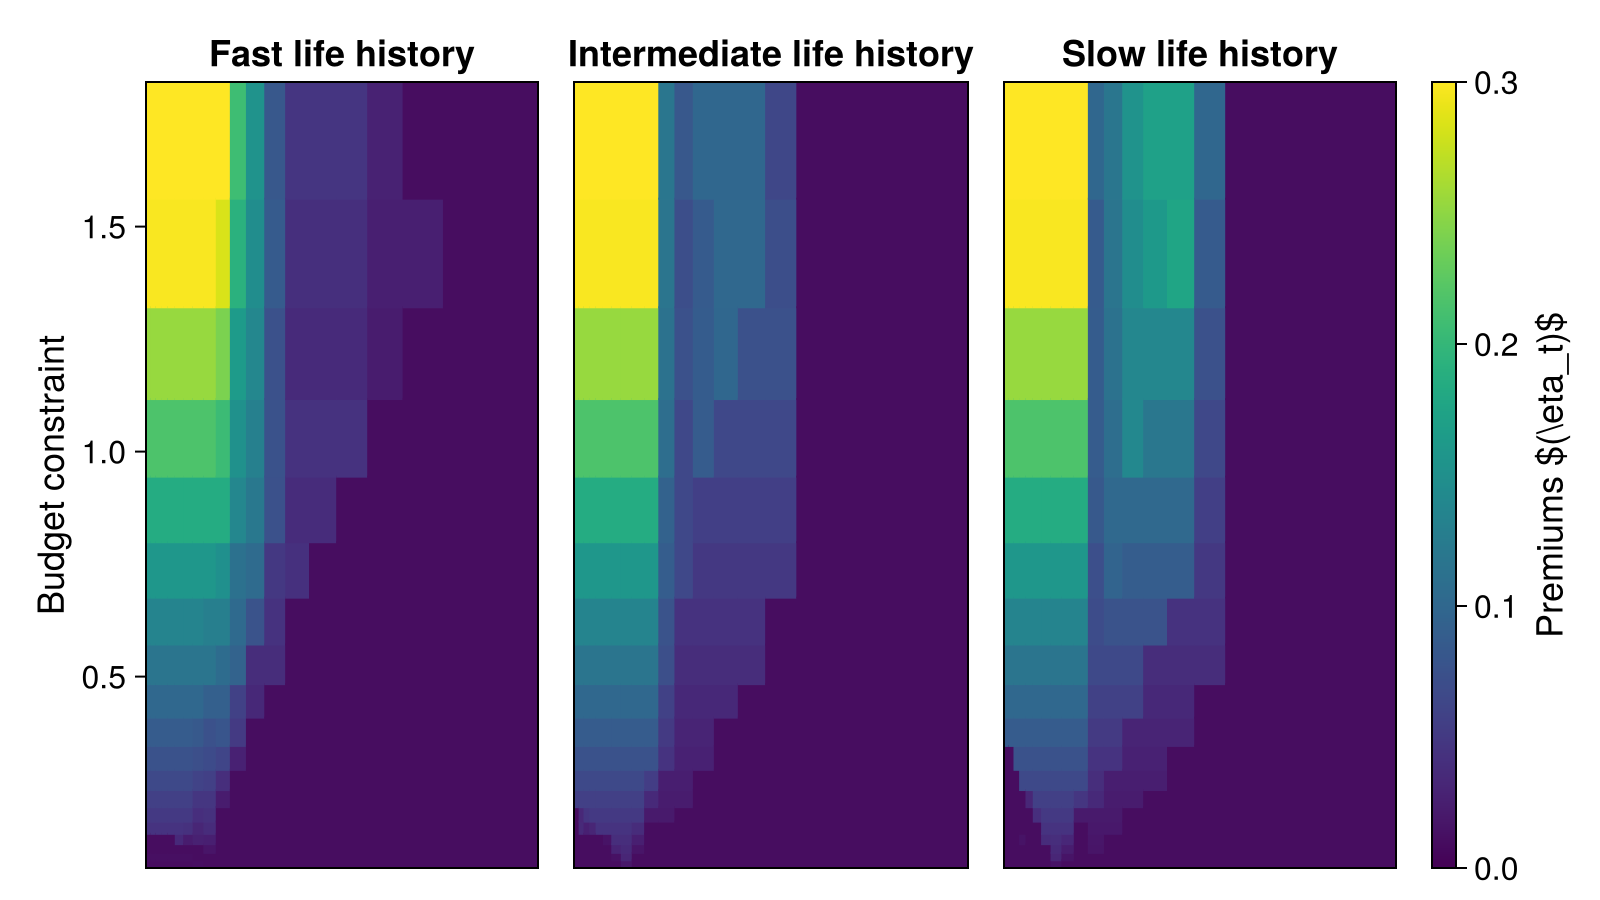

In [89]:
using CairoMakie
using LaTeXStrings
coverage_short = η_s_short./η̄_s_short
coverage_intermediate = η_s_intermediate./η̄_s_intermediate
coverage_long = η_s_long./η̄_s_long

f = Figure(size = (800,450))
ax1 = CairoMakie.Axis(f[1, 1], title = "Fast life history", ylabel = string("Budget constraint"), 
            xticklabelsize = 0, xticksize = 0, titlesize = 18,ylabelsize = 18,yticklabelsize = 16)
ax2 = CairoMakie.Axis(f[1, 2], title = "Intermediate life history",
            xticklabelsize = 0, xticksize = 0,yticklabelsize=0,yticksize=0, titlesize = 18)
ax3 = CairoMakie.Axis(f[1, 3], title = "Slow life history", 
            xticklabelsize = 0, xticksize = 0,yticklabelsize=0,yticksize=0, titlesize = 18)

centers_x = collect(exp.(state_grid_short[1]))
centers_y = collect(exp.(state_grid_short[2]))
ind = 2

data1 = η_s_short[:,:,2,1].+0.01
data2 = η_s_intermediate[:,:,2,1].+0.01
data3 = η_s_long[:,:,2,1].+0.01

scale = ReversibleScale(x -> x, x -> x)
hm = CairoMakie.heatmap!(ax1, centers_y,  centers_x, data1';colorscale = scale,colorrange = (0.0,0.3))
hm = CairoMakie.heatmap!(ax2, centers_y,  centers_x, data2';colorscale = scale,colorrange = (0.0,0.3))
hm = CairoMakie.heatmap!(ax3, centers_y,  centers_x, data3';colorscale = scale,colorrange = (0.0,0.3))
CairoMakie.Colorbar(f[1, 4], hm,  label = string("Premiums ", L"(\eta_t)"), ticks = [0.0, 0.1, 0.2, 0.3], labelsize = 18, ticklabelsize = 16)
f

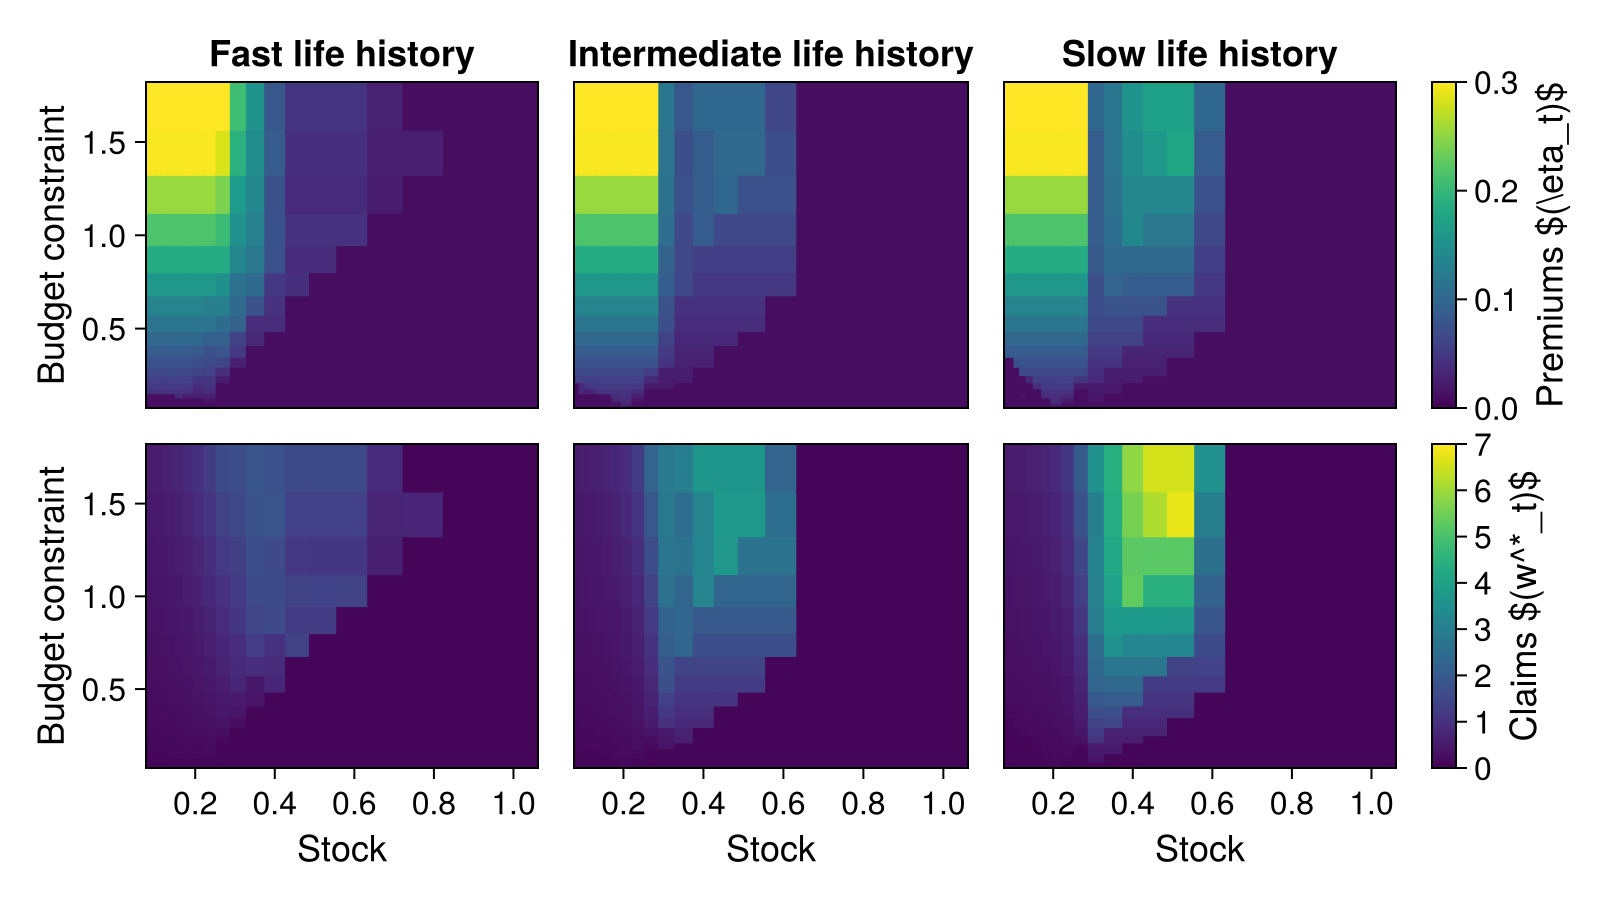

In [90]:
using CairoMakie
ax1 = CairoMakie.Axis(f[2, 1], xlabel = "Stock", ylabel = string("Budget constraint"),
            ylabelsize = 18,xlabelsize = 18,xticklabelsize = 16,yticklabelsize = 16)
ax2 = CairoMakie.Axis(f[2, 2],  xlabel = "Stock",
            yticklabelsize=0,yticksize=0,ylabelsize = 18,xlabelsize = 18,xticklabelsize = 16)
ax3 = CairoMakie.Axis(f[2, 3],  xlabel = "Stock",
            yticklabelsize=0,yticksize=0,ylabelsize = 18,xlabelsize = 18,xticklabelsize = 16)

centers_x = collect(exp.(state_grid_short[1]))
centers_y = collect(exp.(state_grid_short[2]))
ind = 2

data1 = coverage_short[:,:,ind ,1].*claims_short[:,:,ind ,1].+0.1
data2 = coverage_intermediate[:,:,ind ,1].*claims_intermediate[:,:,ind ,1].+0.1
data3 = coverage_long[:,:,ind ,1].*claims_long[:,:,ind ,1].+0.1

scale = ReversibleScale(x -> x, x -> x)
hm = CairoMakie.heatmap!(ax1, centers_y,  centers_x, data1';colorscale = scale,colorrange = (0.0,7.0))
hm = CairoMakie.heatmap!(ax2, centers_y,  centers_x, data2';colorscale = scale,colorrange = (0.0,7.0))
hm = CairoMakie.heatmap!(ax3, centers_y,  centers_x, data3';colorscale = scale,colorrange = (0.0,7.0))
CairoMakie.Colorbar(f[2, 4], hm,  label = string("Claims ", L"(w^*_t)"), labelsize = 18, ticklabelsize = 16)
CairoMakie.save("../../../documents/policy_figure.png",f)
f

In [ ]:
using Pkg 
Pkg.activate("../.")
#Pkg.instantiate()
include("../src/model.jl")

η_s_no_short, η̄_s_no_short, claims_no_short, state_grid_no_short = coverage_levels("no_RA_short")
print("short ")
η_s_no_intermediate, η̄_s_no_intermediate, claims_no_intermediate, state_grid_no_intermediate = coverage_levels("no_RA_intermidiate")
print("int ")
η_s_no_long, η̄_s_no_long, claims_no_long, state_grid_no_long = coverage_levels("no_RA_long")
print("long")

short int long

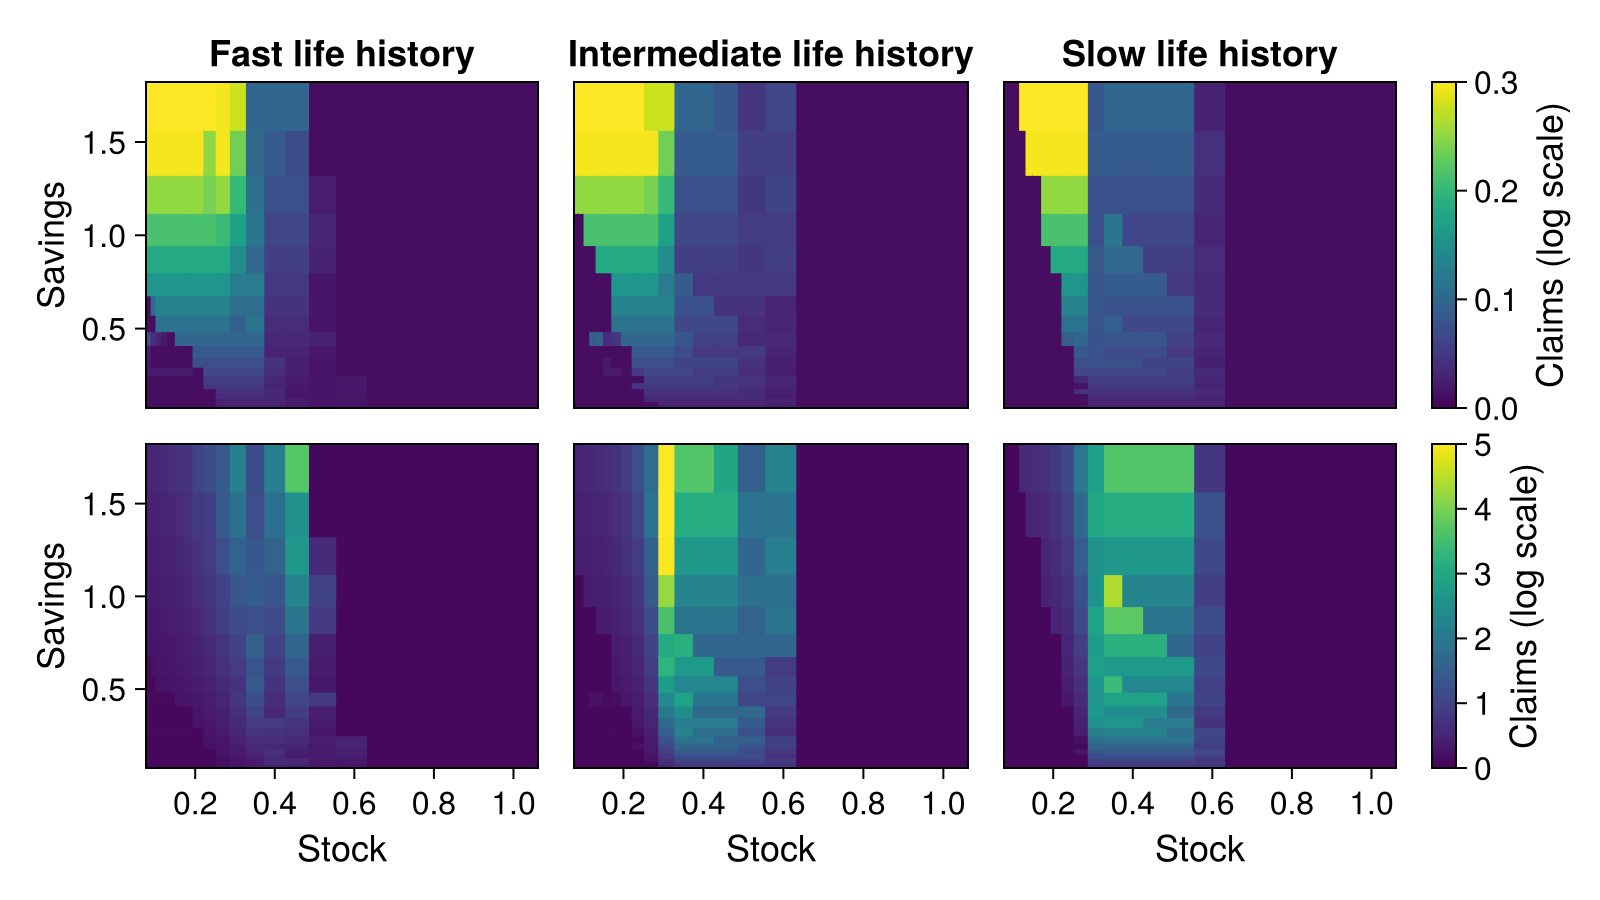

In [ ]:
using CairoMakie
using LaTeXStrings

coverage_short = η_s_no_short./η̄_s_no_short
coverage_intermediate = η_s_no_intermediate./η̄_s_no_intermediate
coverage_long = η_s_no_long./η̄_s_no_long

f = Figure(size = (800,450))
ax1 = CairoMakie.Axis(f[1, 1], title = "Fast life history", ylabel = "Savings", 
            xticklabelsize = 0, xticksize = 0, titlesize = 18,ylabelsize = 18,yticklabelsize = 16)
ax2 = CairoMakie.Axis(f[1, 2], title = "Intermediate life history",
            xticklabelsize = 0, xticksize = 0,yticklabelsize=0,yticksize=0, titlesize = 18)
ax3 = CairoMakie.Axis(f[1, 3], title = "Slow life history", 
            xticklabelsize = 0, xticksize = 0,yticklabelsize=0,yticksize=0, titlesize = 18)

centers_x = collect(exp.(state_grid_no_short[1]))
centers_y = collect(exp.(state_grid_no_short[2]))
ind = 2

data1 = η_s_no_short[:,:,2,1].+0.01
data2 = η_s_no_intermediate[:,:,2,1].+0.01
data3 = η_s_no_long[:,:,2,1].+0.01

scale = ReversibleScale(x -> x, x -> x)
hm = CairoMakie.heatmap!(ax1, centers_y,  centers_x, data1';colorscale = scale,colorrange = (0.0,0.3))
hm = CairoMakie.heatmap!(ax2, centers_y,  centers_x, data2';colorscale = scale,colorrange = (0.0,0.3))
hm = CairoMakie.heatmap!(ax3, centers_y,  centers_x, data3';colorscale = scale,colorrange = (0.0,0.3))
CairoMakie.Colorbar(f[1, 4], hm,  label = "Premiums", ticks = [0.0, 0.1, 0.2, 0.3], labelsize = 18, ticklabelsize = 16)


ax1 = CairoMakie.Axis(f[2, 1], xlabel = "Stock", ylabel = "Savings",
            ylabelsize = 18,xlabelsize = 18,xticklabelsize = 16,yticklabelsize = 16)
ax2 = CairoMakie.Axis(f[2, 2],  xlabel = "Stock",
            yticklabelsize=0,yticksize=0,ylabelsize = 18,xlabelsize = 18,xticklabelsize = 16)
ax3 = CairoMakie.Axis(f[2, 3],  xlabel = "Stock",
            yticklabelsize=0,yticksize=0,ylabelsize = 18,xlabelsize = 18,xticklabelsize = 16)

centers_x = collect(exp.(state_grid_short[1]))
centers_y = collect(exp.(state_grid_short[2]))
ind = 2

data1 = coverage_short[:,:,ind ,1].*claims_short[:,:,ind ,1].+0.1
data2 = coverage_intermediate[:,:,ind ,1].*claims_intermediate[:,:,ind ,1].+0.1
data3 = coverage_long[:,:,ind ,1].*claims_long[:,:,ind ,1].+0.1

hm = CairoMakie.heatmap!(ax1, centers_y,  centers_x, data1';colorscale = scale,colorrange = (0.0,5.0))
hm = CairoMakie.heatmap!(ax2, centers_y,  centers_x, data2';colorscale = scale,colorrange = (0.0,5.0))
hm = CairoMakie.heatmap!(ax3, centers_y,  centers_x, data3';colorscale = scale,colorrange = (0.0,5.0))
CairoMakie.Colorbar(f[2, 4], hm,  label = "Claims", labelsize = 18, ticklabelsize = 16)
CairoMakie.save("../../../documents/policy_figure_no_RA.png",f)
f

In [38]:
(-3:1.0:1.0, string.(round.(10 .^(-3:1.0:1.0),digits = 3)))

(-3.0:1.0:1.0, ["0.001", "0.01", "0.1", "1.0", "10.0"])

In [34]:
10 .^(-3:1.0:1.0)

5-element Vector{Float64}:
  0.001
  0.010000000000000002
  0.1
  1.0
 10.0

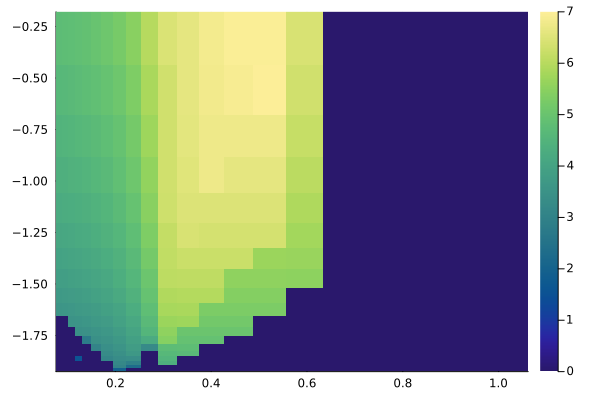

In [9]:
coverage_long = η_s_long./η̄_s_long
p1=Plots.heatmap(exp.(state_grid_short[2]),exp.(state_grid_short[1]).-2,
                coverage_long[:,:,2,1].*claims_long[:,:,2,1].+1e-3,
                clim = (0,7.0), c = :haline, colorbar_scale = :log10)